# Univariate LSTM model (Extracted Features)

**Reduced feature set (feature extraction using PCA)**

Author: Pete King

Here we test an LSTM model's ability to predict near-term volatility using a reduced set of features extracted from macroeconomic and other data, and compare results to the limited-feature and full-feature models.


In [1]:
#123456789012345678901234567890123456789012345678901234567890123456789012345678
import json
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (
    make_scorer,
    r2_score,
    mean_absolute_error,
    root_mean_squared_error,
    mean_squared_error
)

import data_prep as dp
import models

# Global variables
DATA_FOLDER = 'data/train-val-test/'
TRAIN_DATA_FILE = DATA_FOLDER + 'train_etf_data.csv'
PCA_TRAIN_DATA_FILE = DATA_FOLDER + 'train_pca_data.csv'
VAL_DATA_FILE = DATA_FOLDER + 'val_etf_data.csv'
PCA_VAL_DATA_FILE = DATA_FOLDER + 'val_pca_data.csv'
TICKER = 'SPY'
SEQUENCE_LENGTH = 21  # No. observations in each input sequence to LSTM
BATCH_SIZE = 5  # For DataLoader

## I. Data Preparation

### Import and inspect financial data

In [2]:
train_df = dp.make_pca_df(TRAIN_DATA_FILE, PCA_TRAIN_DATA_FILE, TICKER)
val_df = dp.make_pca_df(VAL_DATA_FILE, PCA_VAL_DATA_FILE, TICKER)
train_df

,SPY_vol-h,SPY_vol_target,PCA_vol-1,PCA_vol-2,PCA_macro-1,PCA_macro-2,PCA_macro-3,PCA_macro-4,PCA_hvol-1,PCA_hvol-2,PCA_hvol-3,PCA_hret-1,PCA_hret-2,PCA_hret-3
date,,,,,,,,,,,,,,
2015-10-22,0.007990,0.008038,-0.060385,-0.049302,-0.045180,-0.042780,-0.051164,-0.030192,-0.027020,-0.035612,-0.031673,0.003920,-0.004416,-0.028761
2015-10-23,0.008700,0.007682,-0.019623,-0.042593,-0.040932,-0.026452,-0.008330,-0.036960,-0.000326,-0.024071,-0.030029,-0.043408,-0.038998,-0.035716
2015-10-26,0.008729,0.007669,-0.048401,-0.050450,-0.037413,-0.043599,-0.024643,0.013070,-0.043886,-0.037661,-0.007188,0.011014,0.006914,0.076367
2015-10-27,0.008519,0.007657,0.080811,0.070985,-0.022329,-0.023923,-0.006781,-0.033949,-0.052711,-0.068107,-0.069678,-0.046203,-0.056724,-0.043523
2015-10-28,0.009114,0.007253,-0.030986,0.005244,0.009962,0.023684,0.088783,0.087957,0.062373,0.050440,0.093646,0.074613,0.138485,0.129804
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2022-11-25,0.007469,0.012897,0.308083,0.293317,0.318319,0.347146,0.318630,0.352572,0.230029,0.244636,0.167978,0.168873,0.253616,0.223574
2022-11-28,0.008508,0.012706,0.216470,0.328980,0.303408,0.250322,0.259765,0.119006,0.294609,0.296493,0.182851,0.184875,0.276096,0.106277
2022-11-29,0.008086,0.013284,0.116745,0.214495,0.206188,0.362023,0.225342,0.231037,0.320214,0.402303,0.318870,0.307361,0.372419,0.285724


In [3]:
val_df

,SPY_vol-h,SPY_vol_target,PCA_vol-1,PCA_vol-2,PCA_macro-1,PCA_macro-2,PCA_macro-3,PCA_macro-4,PCA_hvol-1,PCA_hvol-2,PCA_hvol-3,PCA_hret-1,PCA_hret-2,PCA_hret-3
date,,,,,,,,,,,,,,
2023-01-03,0.010242,0.011025,0.453110,0.416835,0.381414,0.326702,0.354621,0.360311,0.337204,0.291585,0.291259,0.358576,0.305696,0.317675
2023-01-04,0.010177,0.011143,0.311223,0.310984,0.294959,0.261770,0.240383,0.213406,0.250842,0.217873,0.185065,0.198466,0.206405,0.258067
2023-01-05,0.010796,0.010940,0.235417,0.230884,0.254676,0.296916,0.303690,0.282478,0.260471,0.297770,0.289716,0.382678,0.367219,0.349151
2023-01-06,0.012081,0.010161,0.388915,0.363785,0.384096,0.367638,0.377479,0.353326,0.390000,0.430783,0.401736,0.431695,0.521250,0.756041
2023-01-09,0.011195,0.010439,0.699941,0.724333,0.684553,0.786744,0.791241,0.633941,0.517984,0.574988,0.709907,0.622068,0.578386,0.536060
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2024-08-26,0.009243,0.008510,0.509651,0.481606,0.525170,0.567170,0.541915,0.505196,0.598294,0.651030,0.650908,0.698193,0.788185,0.639709
2024-08-27,0.007682,0.008549,0.554635,0.607626,0.603924,0.728833,0.711125,0.669326,0.697178,0.710301,0.669767,0.606121,0.689005,0.623749
2024-08-28,0.007836,0.008460,0.716737,0.673490,0.504542,0.574394,0.530578,0.569836,0.579799,0.571859,0.594947,0.587029,0.616483,0.510084


## II. PyTorch Multivariate LSTM Model


### Create Datasets and DataLoaders

In [4]:
# Separate features from labels; discard daily returns as a feature. Note 
# that we capture recent returns (past 2-weeks) in one of the PCA features.
data_cols, label_col = dp.get_X_y_cols(train_df, returns=False)
X_train, y_train = train_df[data_cols].copy(), train_df[label_col].copy()
X_val, y_val = val_df[data_cols].copy(), val_df[label_col].copy()
# Model Training
train_dataset = dp.FinancialDataset(
    X_train.astype(np.float32).values,
    y_train.astype(np.float32).values,
    sequence_length=SEQUENCE_LENGTH
)
train_dataloader = dp.DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=False, drop_last=False
)
# Model Evaluation
val_dataset = dp.FinancialDataset(
    X_val.astype(np.float32).values,
    y_val.astype(np.float32).values,
    sequence_length=SEQUENCE_LENGTH
)
val_dataloader = dp.DataLoader(
    val_dataset, batch_size=BATCH_SIZE, shuffle=False, drop_last=False
)

In [5]:
# Inspect first sample and label in training dataset
X_0, y_0 = train_dataset[0]
print(f'Shape of first training sample: {X_0.shape}')
print(f'Shape of first training label: {y_0.shape}')

Shape of first training sample: torch.Size([21, 13])
Shape of first training label: torch.Size([1])


In [6]:
# Inspect batch dimensions from dataloader
batched_data_0, batched_labels_0 = next(iter(train_dataloader))
print(f'Shape of first batch of data: {batched_data_0.shape}')
print(f'Shape of first batch of labels: {batched_labels_0.shape}')

Shape of first batch of data: torch.Size([5, 21, 13])
Shape of first batch of labels: torch.Size([5, 1])


### Instantiate and train LSTM model

Here we return to a reduced hidden layer size due to the smaller set of input features.

In [7]:
# Define LSTM parameters
input_size = len(data_cols)  # Number of features in data (x)
hidden_size = 16  # Number of 'neurons' (features) in each hidden layer
num_layers = 1  # Number of LSTM layers in the model stack
batch_first = True  # Determines order of dimensions for input/output tensors
bidirectional = False  # If True, becomes a bidirectional LSTM
proj_size = 0  # If > 0, will use LSTM with projections of corresponding size

# Define variables for LSTM input/output tensor dimensions IAW PyTorch docs
N = BATCH_SIZE  # Batch size
L = SEQUENCE_LENGTH  # Sequence length (no. timestamps in rolling window)
D = int(bidirectional) + 1   # D = 1 (not birectional) or 2 (bidirectional)
H_in = input_size
H_cell = hidden_size
H_out = (proj_size if proj_size > 0 else H_in)

# Define number of dimensions in target labels (y)
label_size = len(label_col)

In [8]:
# Set an accelerator device (e.g., CUDA) if available.
if torch.accelerator.is_available():
    device = torch.accelerator.current_accelerator().type
else:
    device = 'cpu'

print(f'Device: {device}')

Device: cpu


In [9]:
# Instantiate LSTM and assign to device
model = models.FinancialLSTM(
    input_size=input_size,
    label_size=label_size,
    hidden_size=hidden_size,
    num_layers=num_layers,
    batch_first=batch_first,
    bidirectional=bidirectional,
    proj_size=proj_size
).to(device)
print(model)

FinancialLSTM(
  (lstm): LSTM(13, 16, batch_first=True)
  (fc): Linear(in_features=16, out_features=1, bias=True)
)


#### Loss function and Optimizer


In [10]:
# Define loss function and optimizer
# For multivariate loss, set parameter reduction='none'
loss_fn = torch.nn.L1Loss(reduction='mean')
optimizer = torch.optim.Adam(model.parameters())

In [11]:
# Train and evaluate model
epochs = 100
all_preds = []
print(f'Training model over {epochs} epochs...')
for epoch in range(epochs):
    loss_trn = models.train_model(train_dataloader, model, loss_fn, optimizer)
    loss_val, preds = models.evaluate_model(val_dataloader, model, loss_fn)
    all_preds.append(preds)
    if epochs <= 20:
        print(f'Epoch {epoch + 1}')
        print(f'Training loss:   {loss_trn}')
        print(f'Validation loss: {loss_val}')
    else:
        if (epoch + 1) % 10 == 0:
            print(f'Epoch {epoch + 1}')
            print(f'Training loss:   {loss_trn}')
            print(f'Validation loss: {loss_val}')

Training model over 100 epochs...
Epoch 10
Training loss:   0.004635216668248177
Validation loss: 0.009634893387556076
Epoch 20
Training loss:   0.0018486339831724763
Validation loss: 0.005876082926988602
Epoch 30
Training loss:   0.004230435937643051
Validation loss: 0.007946358062326908
Epoch 40
Training loss:   0.0035257793497294188
Validation loss: 0.00782355573028326
Epoch 50
Training loss:   0.00407272856682539
Validation loss: 0.008523307740688324
Epoch 60
Training loss:   0.003448180854320526
Validation loss: 0.007920621894299984
Epoch 70
Training loss:   0.003407112555578351
Validation loss: 0.008098041638731956
Epoch 80
Training loss:   0.003358683316037059
Validation loss: 0.00797106884419918
Epoch 90
Training loss:   0.0034513596910983324
Validation loss: 0.00812822300940752
Epoch 100
Training loss:   0.003943862859159708
Validation loss: 0.008808688260614872


## III. Analyze Results

### Plot of predictions vs labels (final epoch)


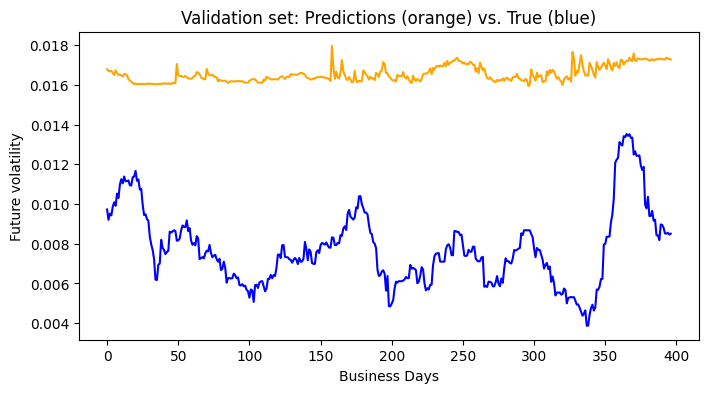

In [12]:
x = range(len(val_dataset))
labels = [val_dataset[i][1]for i in range(len(x))]

fig = plt.figure(figsize=(8, 4))
ax = fig.subplots()
ax.set_title('Validation set: Predictions (orange) vs. True (blue)')
ax.set_ylabel('Future volatility')
ax.set_xlabel('Business Days')
ax.plot(x, labels, color='blue')
ax.plot(x, np.asarray(preds), color='orange')

It's not entirely clear whether the extracted features provide an overall benefit to the model.  Compared to the model with limited input (only return and volatility for the ETF in question), this model is less consistent.  Sometimes the forecast is very spot-on, but other times it misjudges what the market will do and goes in the wrong direction.  Whereas the limited-input model was consistently biased but also tracked consistently with the contours of future volatility figures.

In [13]:
metrics = {
    'R2': r2_score,
    'MAE': mean_absolute_error,
    'RMSE': root_mean_squared_error,
    'MSE': mean_squared_error
}
for metric, scorer in metrics.items():
    print(metric + f': {scorer(labels, np.asarray(preds) - 0.0058)}')

R2: -2.356572151184082
MAE: 0.0031922440975904465
RMSE: 0.0035145427100360394
MSE: 1.2352011253824458e-05
